In [2]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.utils.data import  DataLoader,Subset
import torch.optim as optim
from torchsummary import summary
import torch.nn.functional as F
from torchvision import transforms,datasets
import matplotlib.pyplot as plt

device= torch.device ('cuda'if torch.cuda==True else 'cpu')


In [3]:
transform=transforms.Compose([transforms.Resize((64,64)),
                              transforms.ToTensor(),
                              transforms.Normalize((0.5),
                                                   (0.5))])
train_dataset=datasets.MNIST(root='data',
                             train=True,
                             download=True,
                             transform=transform)

subset_indices=list(range(9000))
subset_data_set=Subset(train_dataset,subset_indices)

data_loader = DataLoader(subset_data_set,batch_size=200,shuffle=True)


In [4]:
class UnetAutoEncoder(nn.Module):
  def __init__(self,input_features):
    super().__init__()
    #Encoder
    self.encoder_=nn.Sequential(
        #Encoder 1
        nn.Conv2d(input_features,64,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.Conv2d(64,64,kernel_size=3,padding=1),
        nn.ReLU(),

        #Encoder 2
        nn.MaxPool2d(2),
        nn.Conv2d(64,128,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.Conv2d(128,128,kernel_size=3,padding=1),
        nn.ReLU(),

        #Encoder 3
        nn.MaxPool2d(2),
        nn.Conv2d(128,256,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.Conv2d(256,256,kernel_size=3,padding=1),
        nn.ReLU(),

        #Encoder 4
        nn.MaxPool2d(2),
        nn.Conv2d(256,512,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.Conv2d(512,512,kernel_size=3,padding=1),
        nn.ReLU()
    )

    #Bottleneck
    self.bottleneck_=nn.Sequential(
        nn.MaxPool2d(2),
        nn.Conv2d(512,1024,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.Conv2d(1024,1024,kernel_size=3,padding=1),
        nn.ReLU()
    )
    #Decoder
    self.decoder_= nn.Sequential(#Decoder 1
            nn.ConvTranspose2d(1024,512,kernel_size=2,stride=2),
            nn.Conv2d(512,512,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.Conv2d(512,512,kernel_size=3,padding=1),
            nn.ReLU(),

            #Decoder 2
            nn.ConvTranspose2d(512,256,kernel_size=2,stride=2),
            nn.Conv2d(256,256,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.Conv2d(256,256,kernel_size=3,padding=1),
            nn.ReLU(),

            #Decoder 3
            nn.ConvTranspose2d(256,128,kernel_size=2,stride=2),
            nn.Conv2d(128,128,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.Conv2d(128,128,kernel_size=3,padding=1),
            nn.ReLU(),

            #Decoder 4
            nn.ConvTranspose2d(128,64,kernel_size=2,stride=2),
            nn.Conv2d(64,64,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.Conv2d(64,64,kernel_size=3,padding=1),
            nn.ReLU(),

            #output Layer
            nn.Conv2d(64,1,kernel_size=1)
            )

  def forward(self,x):
    x=self.encoder_(x)
    encoder=x.clone()
    x=self.bottleneck_(x)
    x=self.decoder_(x)
    return(x,encoder)

  # Encoder
  def encoder(self,x):
    x=self.encoder_(x)    
    return(x)

  # Bottleneck
  def bottleneck(self,x):
    x=self.bottleneck_(x)
    print('bottleneck')
    return(x)

  #Decoder
  def decoder (self,x):
    x=self.decoder_(x)
    return x


In [5]:
class SparseAutoEncoder(UnetAutoEncoder):
    def __init__(self,in_dim,s_lambda=1e-6,s_target=0.05,xavier_nprm_init=True):
        super().__init__(in_dim)
        self.sparsity_lambda=s_lambda
        self.sparsity_target=s_target
        self.xavier_nprm_init=xavier_nprm_init
        # if self.xavier_nprm_init:
        #     nn.init.xavier_uniform_(self.encoder_.weight)
        #     nn.init.xavier_uniform_(self.encoder_.bias,0)

    def sparsity_penalty(self,encoded):
        rho_hat=torch.mean(encoded,dim=(0,2,3))
        rho=self.sparsity_target
        epsilon= 1e-3
        rho_hat=torch.clamp(rho_hat,min=epsilon,max=1-epsilon)
        # print("rho_hat min:", rho_hat.min().item(), "max:", rho_hat.max().item())
        kl_divergence=rho*torch.log(rho/rho_hat)+(1-rho)*torch.log((1-rho)/(1-rho_hat))
        sparsity_penalty=torch.sum(kl_divergence)
        return self.sparsity_lambda*sparsity_penalty
    
    def loss_function(self,x_hat,x,encoded):
        mse=F.mse_loss(x_hat,x)
        sparsity_loss=self.sparsity_penalty(encoded)
        # print(f'MSE={mse}')
        # print(f'Sparsity={sparsity_loss}')
        return mse+sparsity_loss

In [6]:
#Train the model
def train_model(model,dataloader,epochs,optimizer):
    for epoch in range(epochs):
        total_loss=0
        for records,_ in dataloader:
            records=records.to(device)
            optimizer.zero_grad()
            decoded,encoded=model.forward(records)
            loss=model.loss_function(decoded,records,encoded)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss+=loss.item()
        print(f'Epoch: {epoch+1}/{epochs}- Train L: {float(total_loss/len(data_loader))}')

In [7]:
model=SparseAutoEncoder(1)
model.to(device)
optimizer = optim.Adam(model.parameters(),lr=0.0005)
epochs=20

In [8]:
train_model(model,data_loader,epochs,optimizer)

Epoch: 1/20- Train L: 0.7155735366874271
Epoch: 2/20- Train L: 0.293038828836547
Epoch: 3/20- Train L: 0.2225910892089208
Epoch: 4/20- Train L: 0.1489120086034139
Epoch: 5/20- Train L: 0.0928546044561598
Epoch: 6/20- Train L: 0.05692473625143369
Epoch: 7/20- Train L: 0.03892983454797003
Epoch: 8/20- Train L: 0.029979663259453244
Epoch: 9/20- Train L: 0.022251646717389426
Epoch: 10/20- Train L: 0.018637736990220016
Epoch: 11/20- Train L: 0.01635343771841791
Epoch: 12/20- Train L: 0.015859643100864358
Epoch: 13/20- Train L: 0.012916817495392429
Epoch: 14/20- Train L: 0.011874779044753975
Epoch: 15/20- Train L: 0.010934780620866351
Epoch: 16/20- Train L: 0.010290192253887654
Epoch: 17/20- Train L: 0.01002697374464737
Epoch: 18/20- Train L: 0.011385408416390418
Epoch: 19/20- Train L: 0.008130187913775445
Epoch: 20/20- Train L: 0.008546257370875941


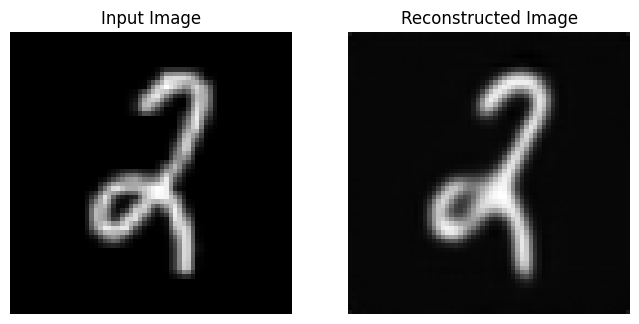

In [23]:
# Get one sample
data_loader1 = DataLoader(subset_data_set,batch_size=1,shuffle=True)
data_iter = iter(data_loader1)
img, label = next(data_iter)  # img shape: (1,1,64,64)

# Pass through model
model.eval()
with torch.no_grad():
    output, _ = model(img)

# Prepare for plotting
input_img = img.squeeze().cpu().numpy()
output_img = output.squeeze().cpu().numpy()

# De-normalize if needed (from [-1,1] back to [0,1])
input_img = (input_img * 0.5) + 0.5
output_img = (output_img * 0.5) + 0.5

# Plot side by side
plt.figure(figsize=(8,4))

# Input
plt.subplot(1,2,1)
plt.imshow(input_img, cmap='gray')
plt.title("Input Image")
plt.axis('off')

# Output
plt.subplot(1,2,2)
plt.imshow(output_img, cmap='gray')
plt.title("Reconstructed Image")
plt.axis('off')

plt.show()